#### 로지스틱 회귀
```
공부한 시간  데이터를 복? 합격(여부를 예측)
공부시간에 비례해서 점수를 부여
공부 1시간에 10점을 부여
--> 선형 방정식
합격점수(z) = w*(공부시간) + b
W(가중치) : 중요도 1시간 당 점수(10점)
b(편향) : 기본점수(-50, 5시간)

문제점 : 합격점수에 해당하는 100점이 나올수도 있지만 -200점이 나올수도 있다.
분류를 할려면 합격 , 불합격을 판단해야하는 데 그러기위해 필요한것은 확률
방정식의 값으로 확률을 계산(0% ~ 100%)
```

#### 점수를 확률로 바꿔야 한다. (시그모이드 함수) 0~1사이의 확률 값으로 변경
```
합격확률 = 시그모이드(z) = 1 / 1 + e^-z
합격점수가 높으면 1에 가깝고
낮으면 0에 가깝다.
합격점수가 0이면 정확히 0.5(50%) - 임계값
```

#### 비용함수(손실함수) : 모델이 얼마나 틀렸는지 측정 로지스틱은 로그함수를 사용
```
합격(정답=1)
모델이 99% 합격예측 == > 벌점은 거의 0점
모델이 1% 합격예측 == > 벌점은 크게(무한대에 가깝게)

불합격(정답 = 0)
모델이 1%로 합격을 예측 -> 잘 맞춤 벌점이 거의 0점
모델이 99%로 합격을 예측 -> 완전 틀림 벌점을 아주크게

log loss 원리 
w,b를 찾음... 손실함수를 이용해서 비용이 가장낮을때 
```

##### 비용이 최저인 값을 찾아나가는 과정 : 경사하강법
##### 너무 완벽한 모델..(학습에 대해서)
```
규제(Regularozation) 모델이 너무 복잡해지지 않도록 패널티 혹은 중요도를 간결하게 설정한다.
L2규제(Ridge) : w(중요도) 값이 너무 커지는 것을 막는다. 가중치(w) 제곱의 합만큼 패널티 추가
L1규제(Lasso) : 어떤 특징이 별로 안중요할거 같은 w(중요도)를 그냥 0으로 만든다.
불필요한 특성을 제거한다.
가중치들의 절대값의 합을 패널티로 추가 - feature selecter 역활도 겸함 ^
```

![화면 캡처 2025-10-21 153659.png](<attachment:화면 캡처 2025-10-21 153659.png>)
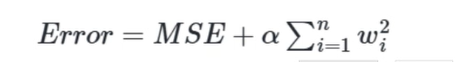

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()
X = data.data
y = data.target

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.3,stratify=y)

clr = LogisticRegression(max_iter=10000)
clr.fit(x_train,y_train)
predict = clr.predict(x_test)
print(predict[:5],  y_test[:5])

# 모델이 각 샘플이 특정 클래스에 속할 **확률**을 제시한 값
predict_proba = clr.predict_proba(x_test)
predict_proba[:5]

[1 1 1 0 1] [1 1 1 1 1]


array([[1.63210767e-03, 9.98367892e-01],
       [3.23749857e-04, 9.99676250e-01],
       [1.49857682e-04, 9.99850142e-01],
       [9.88281984e-01, 1.17180165e-02],
       [6.83683458e-03, 9.93163165e-01]])

In [61]:
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# --- 시각화 함수 (공통) ---
def plot_decision_boundary(model, X_orig, y_orig, poly_transformer, scaler_transformer, title, subplot_ax):
    """모델의 결정 경계를 그려주는 함수"""
    # 1. 그래프를 그릴 영역을 정의합니다.
    x_min, x_max = X_orig[:, 0].min() - 0.5, X_orig[:, 0].max() + 0.5
    y_min, y_max = X_orig[:, 1].min() - 0.5, X_orig[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # 2. 그래프 영역의 모든 점들을 모델이 예측할 수 있도록 변환합니다.
    grid_poly = poly_transformer.transform(np.c_[xx.ravel(), yy.ravel()])
    grid_scaled = scaler_transformer.transform(grid_poly)

    # 3. 변환된 점들을 모델로 예측합니다.
    Z = model.predict(grid_scaled)
    Z = Z.reshape(xx.shape)

    # 4. 결정 경계와 원본 데이터 포인트를 그립니다.
    subplot_ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    subplot_ax.scatter(X_orig[:, 0], X_orig[:, 1], c=y_orig, cmap=plt.cm.coolwarm, edgecolors='k')
    subplot_ax.set_title(title)
    subplot_ax.set_xlabel("Feature 1")
    subplot_ax.set_ylabel("Feature 2")

In [62]:
# 과적합을 임의로 만들어서 시각화
# 1. 규제알고리즘을 적용
# 2. 모델을 경량화 모델의 복잡도를 높이는 요소를 제거
# 3. 추가 데이터르 투입해서 학습

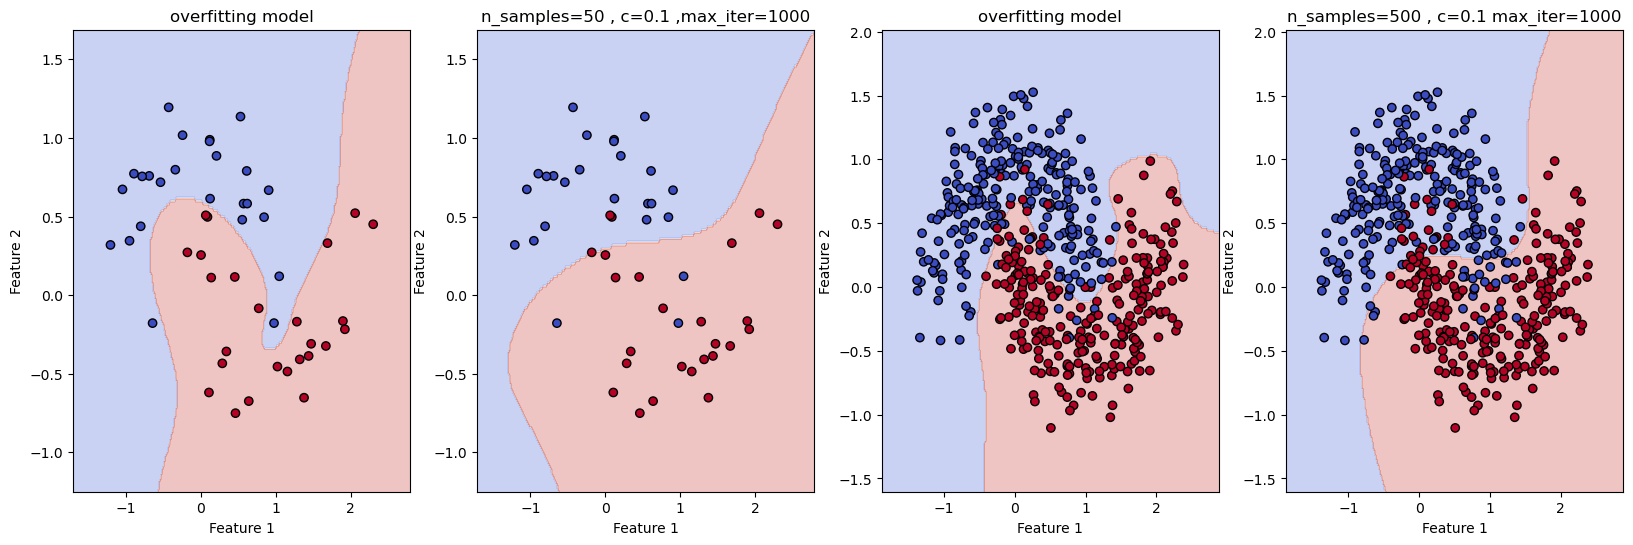

In [63]:
fig, axes = plt.subplots(1,4,figsize=(20,6))
# 과적합 모델
X_small, y_small = make_moons(n_samples=50, noise=0.25, random_state=45)

# 과적합을 유도하고자 고차항 특성으로 변환
poly = PolynomialFeatures(degree=10,include_bias=True)
X_poly_small = poly.fit_transform(X_small)

# 데이터 스케일링
scaler = StandardScaler()
X_scaled_small = scaler.fit_transform(X_poly_small)

# 모델 훈련(데이터 50, 약한 규제)
log_reg_overfit = LogisticRegression(C=1000,max_iter=10000) # C가 규제강도 클수록 규제를 약하게 max_iter는 학습횟수
log_reg_overfit.fit(X_scaled_small,y_small)

plot_decision_boundary(log_reg_overfit,X_small,y_small,poly,scaler,'overfitting model',axes[0])

# 규제 적용(데이터 50, 강한규제)
log_reg_regulation = LogisticRegression(C=0.1, max_iter=1000)
log_reg_regulation.fit(X_scaled_small,y_small)

plot_decision_boundary(log_reg_regulation,X_small,y_small,poly,scaler,'n_samples=50 , c=0.1 ,max_iter=1000',axes[1])

# 데이터를 추가(데이터 500, 약한 규제)
X_big, y_big = make_moons(n_samples=500, noise=0.25, random_state=45)

# 과적합을 유도하고자 고차항 특성으로 변환
poly = PolynomialFeatures(degree=10,include_bias=True)
X_poly_big = poly.fit_transform(X_big)

# 데이터 스케일링
scaler = StandardScaler()
X_scaled_big = scaler.fit_transform(X_poly_big)

# 모델 훈련(데이터 500, 약한 규제)
log_reg_overfit = LogisticRegression(C=1000,max_iter=10000) # C가 규제강도 클수록 규제를 약하게 max_iter는 학습횟수
log_reg_overfit.fit(X_scaled_big,y_big)

plot_decision_boundary(log_reg_overfit,X_big,y_big,poly,scaler,'overfitting model',axes[2])

# 규제 적용(데이터 500, 강한규제)
log_reg_regulation = LogisticRegression(C=0.1, max_iter=1000)
log_reg_regulation.fit(X_scaled_big,y_big)

plot_decision_boundary(log_reg_regulation,X_big,y_big,poly,scaler,'n_samples=500 , c=0.1 max_iter=1000',axes[3])

In [64]:
%pip install mlxtend

Note: you may need to restart the kernel to use updated packages.


In [65]:
# 파이프라인을 사용하여 위 절차를 단순화하기
from sklearn.pipeline import Pipeline

# 약한 규제 파이프
pipe1 = Pipeline([
    ('poly',PolynomialFeatures(degree=10)),
    ('scaler',StandardScaler()),
    ('clf',LogisticRegression(C=1000,max_iter=10000))
])

# 강한 규제 파이프
pipe2 = Pipeline([
    ('poly',PolynomialFeatures(degree=10)),
    ('scaler',StandardScaler()),
    ('clf',LogisticRegression(C=0.1, max_iter=1000))
])

# 파이프라인 학습 (원본 데이터로 학습)
pipe1.fit(X, y)
pipe2.fit(X, y)

# 작은 데이터
X_small, y_small = make_moons(n_samples=50, noise=0.25, random_state=45)
# 큰 데이터
X_big, y_big = make_moons(n_samples=500, noise=0.25, random_state=45)

# 서브플롯 생성
fig, axes = plt.subplots(1, 4, figsize=(23, 5))  # 1행 2열

from mlxtend.plotting import plot_decision_regions # 많이 사용하는 함수
plot_decision_regions(X=X_small, y=y_small, clf=pipe1, legend=2, ax=axes[0]) # <--- 바로 이 부분!
plot_decision_regions(X=X_small, y=y_small, clf=pipe2, legend=2, ax=axes[1])
plot_decision_regions(X=X_big, y=y_big, clf=pipe1, legend=2, ax=axes[2])
plot_decision_regions(X=X_big, y=y_big, clf=pipe1, legend=2, ax=axes[3])
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Boundary with Full Pipeline')
plt.show()

MemoryError: Unable to allocate 3.51 TiB for an array with shape (569, 847660528) and data type float64

In [ ]:
import matplotlib.pyplot as plt
# 1. 서브플롯 준비 (1행 4열)
fig, axes = plt.subplots(1, 4, figsize=(20,5))

# 2. 작은 데이터, 약한 규제
pipe1.fit(X_small, y_small)
plot_decision_boundary(pipe1, X_small, y_small, title="Small Data - Weak Reg", subplot_ax=axes[0])

# 3. 작은 데이터, 강한 규제
pipe2.fit(X_small, y_small)
plot_decision_boundary(pipe2, X_small, y_small, title="Small Data - Strong Reg", subplot_ax=axes[1])

# 4. 큰 데이터, 약한 규제
pipe1.fit(X_big, y_big)
plot_decision_boundary(pipe1, X_big, y_big, title="Big Data - Weak Reg", subplot_ax=axes[2])

# 5. 큰 데이터, 강한 규제
pipe2.fit(X_big, y_big)
plot_decision_boundary(pipe2, X_big, y_big, title="Big Data - Strong Reg", subplot_ax=axes[3])

plt.tight_layout()
plt.show()

# TypeError: plot_decision_boundary() missing 2 required positional arguments: 'poly_transformer' and 'scaler_transformer'

#### ROC , AUC
```
정확도 99% 하지만...  데이터가 불균형이라면 좋은 척도가 못된다. ROC, AUC 얼마나 안정적으로 좋은 성능을 내는지를 종합적으로 시각화 모델이 예측한 확률을 기반으로 분류기준점(Threshold)을 꼐속 변경해서 모델의 성능이 어떻게 변하는지 하나의 곡선으로 나타낸다.
```

#### ROC 구성요소 TPR FPR
```
혼동행렬 (p : 1  n : 0)   p:암환자  n : 정상
 TP(True Positive) : 진짜 암인환자를 암이라고 예측  정답
 FN(False Nagative) : 진짜 암인환자를 정상으로 예측  놓친 암환자
 FP(False Positive) : 정상인사람을 암이라고 예측   : 잘못된 예측
 TN(True Nagative) : 정상인 사람을 정상  : 정답

 ROC 곡선의 x와 y축
 y축 : 진짜를 얼마나 잘 찾았나  TPR(True Positive Rate)  실제 양성인 데이터 중에서 모델이 양성으로 올바르게 예측한 비율
 TRP : 민감도 또는 재현율
 실제로 암인데 암이라고 예측 / 실제 모든 암 환자수
 TPR =  TP / TP + FN

 x축 : 가짜를 얼마나 잘못찾았냐.. FPR
 FPR = FP(정상인데 암이라고 예측) / FP + TN(실제 모든 정상인수)
```

#### AUC (Area Under The Curve)
```
ROC 곡선 아래의 면적
1 : 완벽한 모델  ROC가 좌측상단에 붙어 있는 모양
0.5 : 무작위로 찍는것과 같은.. 즉.. 랜덤하게 예측하는 수준 ROC 대각선 직선
< 0.5 : 예측을 반대로.. 잘못된 모델
```

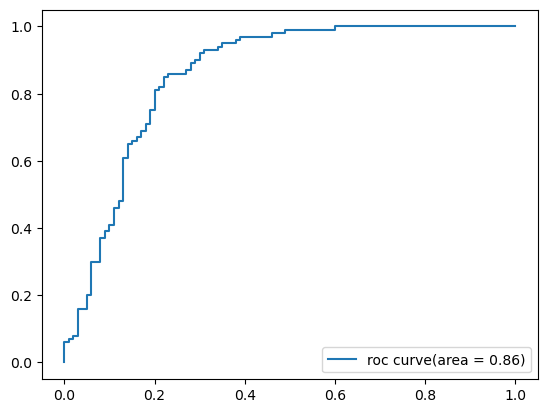

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

X,y = make_classification(n_samples=1000, n_features=20, n_informative=5,
                    n_redundant=0,random_state=42)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

model = LogisticRegression()
model.fit(X_train,y_train)
y_pred_proba = model.predict_proba(X_test)[:,1]

# ROC  AUC
# 실제값과 예측 확률을 사용 FPR  TPR
fpr, tpr, thresholds =  roc_curve(y_test, y_pred_proba)
# fpr tpr 이용 auc를 계산
roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,label = f'roc curve(area = {roc_auc:.2f})')
plt.legend()
plt.show()
